# Appendix A: Fredholm Theory

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix A, printed pp. 531-548; PDF pp. 546-563. Sections: A.1-A.5.

## Chapter Goal

Appendix A is the functional-analytic control room behind smooth moduli spaces. This notebook makes the finite-dimensional data in a Fredholm problem visible: kernel directions, cokernel obstructions, determinant-line signs, regular-value charts, Kuranishi reduction, and the Sard-Smale reduction to ordinary Sard.

The guiding question is:

> How does an infinite-dimensional nonlinear equation become a finite-dimensional, orientable, generically regular local model?

## Computational Translation Guide

| Source idea | Computational model | What to inspect |
| --- | --- | --- |
| Fredholm operator $D:X\to Y$ | finite-rank-defect matrices and SVD ledgers | finite kernel/cokernel and stable index |
| Compact/small perturbation stability | perturbed rectangular operator plus stacked estimate | index survives while defect spaces can move |
| Determinant line $\det(D)$ | path of index-zero matrices crossing the noninvertible stratum | parity of crossings controls orientation sign |
| Regular value and implicit function theorem | nonlinear equation with a right-inverse correction | zero set is graphed over the kernel |
| Pseudoinverse and Kuranishi model | projection to image plus scalar obstruction map | singular points are encoded by a finite obstruction |
| Sard-Smale theorem | split map $(u,v)\mapsto (u^2,v)$ | regular values reduce to finite-dimensional Sard slices |

All prose, code, and figures below are original teaching artifacts. The PDF pages are used only to orient the section coverage and terminology.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "appendix-a"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TOL = 1e-8


def linear_diagnostics(A, tol=TOL):
    A = np.asarray(A, dtype=float)
    target_dim, domain_dim = A.shape
    singular_values = np.linalg.svd(A, compute_uv=False)
    rank = int(np.sum(singular_values > tol))
    kernel_dim = int(domain_dim - rank)
    cokernel_dim = int(target_dim - rank)
    return {
        "target_dimension": int(target_dim),
        "domain_dimension": int(domain_dim),
        "rank": rank,
        "kernel_dimension": kernel_dim,
        "cokernel_dimension": cokernel_dim,
        "index": int(kernel_dim - cokernel_dim),
        "rank_nullity_ok": bool(rank + kernel_dim == domain_dim),
        "singular_values": [float(x) for x in singular_values],
    }


def write_csv(path, rows, fieldnames):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    return path

BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

## Source Coverage and Visual Storyboard

## Library Routing

The source span is short but dense. This cell records a local audit trail: each source section is mapped to an original computational artifact and a check. The resulting JSON files live beside the figures so future workers can see why each artifact exists.


In [2]:
source_coverage = [
    {"section": "A.1", "printed_pages": "531-533", "source_concepts": ["Fredholm definition", "compact-estimate criterion", "compact and small perturbation stability", "index additivity", "dual index relation"], "notebook_artifacts": ["figures/fredholm-index-stability-criterion.png", "checks/fredholm-stability-index-relations.json"]},
    {"section": "A.2", "printed_pages": "533-538", "source_concepts": ["determinant line", "local trivialization by finite-dimensional summand", "regular crossing and mod 2 orientation sign"], "notebook_artifacts": ["figures/determinant-line-crossing-sign.png", "checks/determinant-crossing-signs.json"]},
    {"section": "A.3", "printed_pages": "538-544", "source_concepts": ["inverse function theorem", "regular values", "implicit chart using a right inverse", "Newton-Picard correction"], "notebook_artifacts": ["figures/implicit-newton-picard-chart.png", "checks/implicit-newton-picard.json"]},
    {"section": "A.4", "printed_pages": "545-547", "source_concepts": ["pseudoinverse identities", "kernel/image/cokernel splitting", "finite-dimensional Kuranishi obstruction"], "notebook_artifacts": ["figures/kuranishi-obstruction-map.png", "checks/kuranishi-pseudoinverse-obstruction.json"]},
    {"section": "A.5", "printed_pages": "547-548", "source_concepts": ["Sard-Smale theorem", "local reduction to finite-dimensional Sard", "regular values as a residual set"], "notebook_artifacts": ["figures/sard-smale-finite-reduction.png", "checks/sard-smale-reduction.json"]},
]

visual_storyboard = [
    {"concept": "Fredholm index stability", "representation": "rectangular SVD ledger plus stacked compact-estimate matrix", "library": "NumPy + Matplotlib", "artifact": "figures/fredholm-index-stability-criterion.png", "inspection_target": "Index remains constant while defect spaces can move.", "validation": "rank-nullity, lower bound, perturbation index, composition additivity, dual relation"},
    {"concept": "Determinant-line crossing sign", "representation": "index-zero diagonal paths crossing the noninvertible stratum", "library": "NumPy + Matplotlib + SymPy", "artifact": "figures/determinant-line-crossing-sign.png", "inspection_target": "Each simple crossing flips orientation; two preserve it.", "validation": "endpoint determinant sign ratio equals (-1)^crossing_index"},
    {"concept": "Implicit function chart", "representation": "zero curve graphed over the kernel plus Newton-Picard corrections", "library": "NumPy + Matplotlib", "artifact": "figures/implicit-newton-picard-chart.png", "inspection_target": "The zero set is tangent to the kernel and residuals contract.", "validation": "residual decrease, final residual, tangent slope at origin"},
    {"concept": "Kuranishi obstruction", "representation": "pseudoinverse splitting with scalar obstruction u^2-a", "library": "SymPy + NumPy + Matplotlib", "artifact": "figures/kuranishi-obstruction-map.png", "inspection_target": "Changing the obstruction level creates two, one singular, or no zeros.", "validation": "TDT=T, DTD=D, kernel/cokernel dimensions, zero-count ledger"},
    {"concept": "Sard-Smale local proof shape", "representation": "target-plane critical value set for (u,v)->(u^2,v)", "library": "NumPy + Matplotlib", "artifact": "figures/sard-smale-finite-reduction.png", "inspection_target": "Critical values form a thin finite-dimensional set.", "validation": "sampled critical fraction and derivative ranks"},
]

coverage_payload = {"source": "Appendix A, printed pp. 531-548; PDF pp. 546-563", "sections": source_coverage, "passed": len(source_coverage) == 5}
storyboard_payload = {"chapter_goal": "Make Fredholm finite-dimensional data visible for moduli regularity and orientation.", "visuals": visual_storyboard, "passed": len(visual_storyboard) == 5 and all(v["validation"] for v in visual_storyboard)}
library_routing = {
    "numpy": ["SVD ledgers", "finite-rank defect experiments", "Newton residual grids"],
    "matplotlib": ["index stability, determinant crossing, Kuranishi, Sard-Smale figures"],
    "sympy": ["pseudoinverse identities and exact determinant checks"],
    "networkx": ["Fredholm proof dependency map"],
    "course_artifact_helpers": ["save_json", "save_matplotlib", "display_artifact", "assert_artifact"],
    "passed": True,
}
coverage_path = save_json(coverage_payload, UNIT, "checks", "source-coverage-fredholm-theory.json")
storyboard_path = save_json(storyboard_payload, UNIT, "checks", "visual-storyboard-fredholm-theory.json")
standard_coverage_path = save_json(coverage_payload, UNIT, "checks", "source-coverage.json")
standard_storyboard_path = save_json(storyboard_payload, UNIT, "checks", "visual-storyboard.json")
library_routing_path = save_json(library_routing, UNIT, "checks", "library-routing.json")
display_artifact(standard_coverage_path)
display_artifact(standard_storyboard_path)
display_artifact(library_routing_path)
display_artifact(coverage_path)
display_artifact(storyboard_path)
{"coverage_items": len(source_coverage), "storyboard_items": len(visual_storyboard)}


{'coverage_items': 5, 'storyboard_items': 5}

## A.1 Fredholm Operators: Defect Spaces That Stay Finite

A bounded operator is Fredholm when the kernel is finite-dimensional, the image is closed, and the cokernel is finite-dimensional. The index

$$\operatorname{ind}D=\dim\ker D-\dim\operatorname{coker}D$$

is the dimension budget used later for moduli spaces. The finite model below is not the theorem, since every finite matrix has closed image. It makes the appendix's bookkeeping inspectable: a small perturbation changes the visible defect spaces, but the index survives. The stacked matrix $[D;K_0]$ models the estimate in Lemma A.1.1 by adding a finite-dimensional measurement of the kernel.


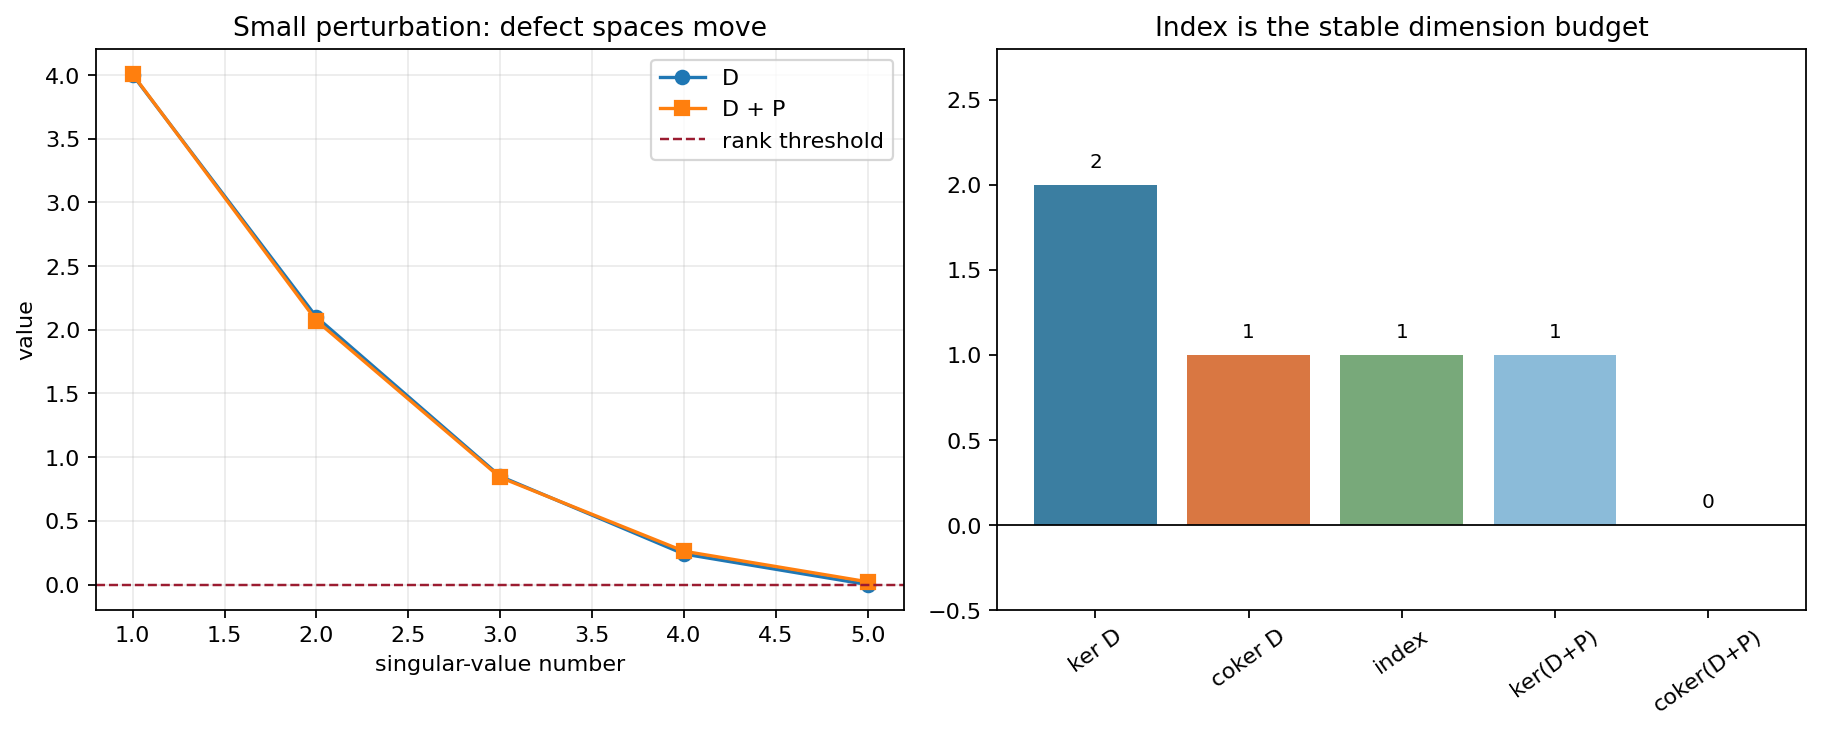

{'rank_nullity_base': True,
 'rank_nullity_perturbed': True,
 'stacked_estimate_positive': True,
 'small_perturbation_index_stable': True,
 'composition_additivity': True,
 'dual_relation': True}

In [3]:
rng = np.random.default_rng(531)
target_dim, domain_dim, base_rank = 5, 6, 4
U, _ = np.linalg.qr(rng.normal(size=(target_dim, target_dim)))
V, _ = np.linalg.qr(rng.normal(size=(domain_dim, domain_dim)))
S = np.zeros((target_dim, domain_dim))
S[:base_rank, :base_rank] = np.diag([4.0, 2.1, 0.85, 0.24])
D = U @ S @ V.T

base_diag = linear_diagnostics(D)
svd_U, _, svd_Vt = np.linalg.svd(D, full_matrices=True)
kernel_basis = svd_Vt.T[:, base_diag["rank"]:]
K0 = kernel_basis.T
stacked = np.vstack([D, K0])
stacked_min_singular = float(np.linalg.svd(stacked, compute_uv=False)[-1])

raw_P = rng.normal(size=D.shape)
P = raw_P / np.linalg.norm(raw_P, ord=2) * 0.055
D_small = D + P
small_diag = linear_diagnostics(D_small)

T = np.hstack([np.eye(base_rank), np.zeros((base_rank, target_dim - base_rank))]) @ U.T
T_diag = linear_diagnostics(T)
TD_diag = linear_diagnostics(T @ D)
adjoint_diag = linear_diagnostics(D.T)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7))
positions = np.arange(1, len(base_diag["singular_values"]) + 1)
axes[0].plot(positions, base_diag["singular_values"], marker="o", label="D")
axes[0].plot(positions, small_diag["singular_values"], marker="s", label="D + P")
axes[0].axhline(TOL, color="#9b1c31", linestyle="--", linewidth=1.1, label="rank threshold")
axes[0].set_xlabel("singular-value number")
axes[0].set_ylabel("value")
axes[0].set_title("Small perturbation: defect spaces move")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

labels = ["ker D", "coker D", "index", "ker(D+P)", "coker(D+P)", "index"]
values = [base_diag["kernel_dimension"], base_diag["cokernel_dimension"], base_diag["index"], small_diag["kernel_dimension"], small_diag["cokernel_dimension"], small_diag["index"]]
axes[1].bar(labels, values, color=["#3b7ea1", "#d97742", "#2f855a", "#8bbbd9", "#ebb284", "#78a97a"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylim(min(values) - 0.5, max(values) + 0.8)
axes[1].set_title("Index is the stable dimension budget")
axes[1].tick_params(axis="x", rotation=35)
for tick, value in zip(axes[1].get_xticks(), values):
    axes[1].text(tick, value + 0.08, str(value), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fredholm_fig = save_matplotlib(fig, UNIT, "figures", "fredholm-index-stability-criterion.png")
plt.close(fig)

fredholm_check = {
    "base_operator": base_diag,
    "small_perturbation_operator": small_diag,
    "small_perturbation_norm": float(np.linalg.norm(P, ord=2)),
    "stacked_estimate_min_singular": stacked_min_singular,
    "stacked_estimate_constant": float(1.0 / stacked_min_singular),
    "composition_operator_T": T_diag,
    "composition_TD": TD_diag,
    "adjoint_operator": adjoint_diag,
    "checks": {
        "rank_nullity_base": bool(base_diag["rank_nullity_ok"]),
        "rank_nullity_perturbed": bool(small_diag["rank_nullity_ok"]),
        "stacked_estimate_positive": bool(stacked_min_singular > TOL),
        "small_perturbation_index_stable": bool(small_diag["index"] == base_diag["index"]),
        "composition_additivity": bool(TD_diag["index"] == base_diag["index"] + T_diag["index"]),
        "dual_relation": bool(adjoint_diag["index"] == -base_diag["index"]),
    },
}
fredholm_check["passed"] = all(fredholm_check["checks"].values())
save_json(fredholm_check, UNIT, "checks", "fredholm-stability-index-relations.json")
display_artifact(fredholm_fig, width=780)
fredholm_check["checks"]


## A.2 Determinant Lines and Crossings

For a Fredholm operator $D$, the determinant line packages the orientation of the kernel with the orientation of the cokernel:

$$\det(D)=\Lambda^{\max}(\ker D)\otimes \Lambda^{\max}(\ker D^*).$$

When the index is zero and a path has invertible endpoints, the determinant line can still twist. A regular crossing is a moment when the kernel appears transversely. The two diagonal paths below model the crossing formula: one simple crossing reverses orientation, while two simple crossings preserve it.


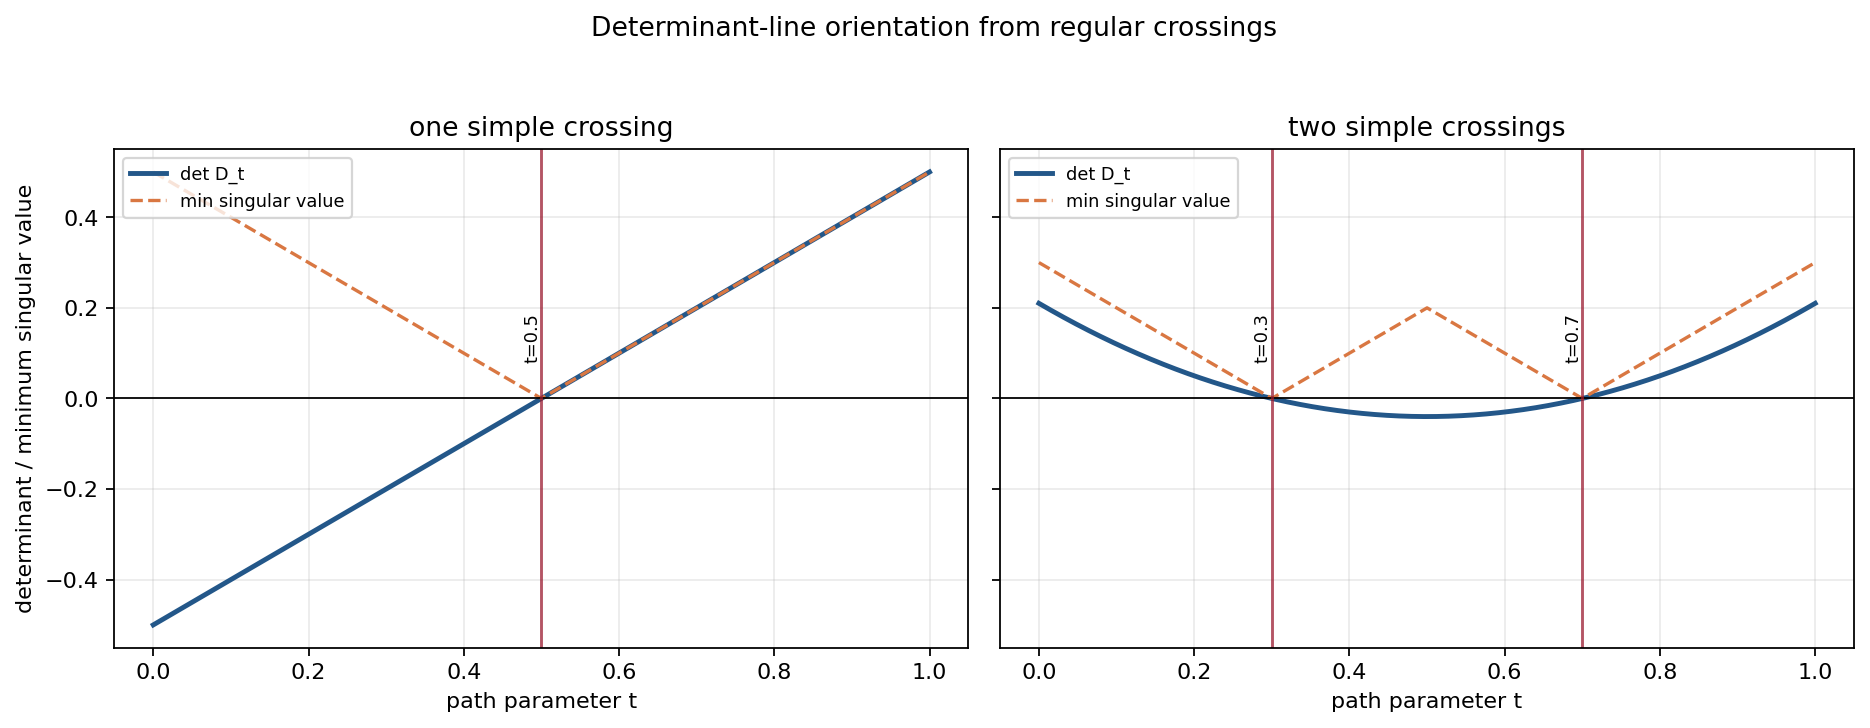

{'paths': [{'path': 'one simple crossing',
   'crossing_times': [0.5],
   'crossing_kernel_dimensions': [1],
   'crossing_index': 1,
   'endpoint_determinant_sign_ratio': -1,
   'formula_sign_minus_one_to_mu': -1,
   'sign_formula_ok': True},
  {'path': 'two simple crossings',
   'crossing_times': [0.3, 0.7],
   'crossing_kernel_dimensions': [1, 1],
   'crossing_index': 2,
   'endpoint_determinant_sign_ratio': 1,
   'formula_sign_minus_one_to_mu': 1,
   'sign_formula_ok': True}],
 'orientation_rule': 'endpoint sign ratio equals (-1)^sum_dim_kernel_at_regular_crossings in these diagonal index-zero models',
 'passed': True}

In [4]:
t_grid = np.linspace(0.0, 1.0, 501)
sym_t = sp.Symbol("t")
path_specs = [
    {"name": "one simple crossing", "crossings": [sp.Rational(1, 2)], "eigenvalue_functions": [lambda t: np.ones_like(t), lambda t: t - 0.5], "symbolic_eigenvalues": [sp.Integer(1), sym_t - sp.Rational(1, 2)]},
    {"name": "two simple crossings", "crossings": [sp.Rational(3, 10), sp.Rational(7, 10)], "eigenvalue_functions": [lambda t: np.ones_like(t), lambda t: t - 0.3, lambda t: t - 0.7], "symbolic_eigenvalues": [sp.Integer(1), sym_t - sp.Rational(3, 10), sym_t - sp.Rational(7, 10)]},
]

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4), sharey=True)
crossing_summaries = []
for ax, spec in zip(axes, path_specs):
    eigenvalues = np.vstack([fn(t_grid) for fn in spec["eigenvalue_functions"]])
    det_values = np.prod(eigenvalues, axis=0)
    min_abs_eigenvalue = np.min(np.abs(eigenvalues), axis=0)
    ax.plot(t_grid, det_values, color="#235789", linewidth=2.2, label="det D_t")
    ax.plot(t_grid, min_abs_eigenvalue, color="#d97742", linestyle="--", label="min singular value")
    ax.axhline(0, color="black", linewidth=0.8)
    for crossing in spec["crossings"]:
        x = float(crossing)
        ax.axvline(x, color="#9b1c31", alpha=0.75, linewidth=1.3)
        ax.text(x, 0.08, f"t={x:g}", rotation=90, va="bottom", ha="right", fontsize=8)
    ax.set_title(spec["name"])
    ax.set_xlabel("path parameter t")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)

    symbolic_det = sp.prod(spec["symbolic_eigenvalues"])
    det_start = int(sp.sign(symbolic_det.subs(sym_t, 0)))
    det_end = int(sp.sign(symbolic_det.subs(sym_t, 1)))
    endpoint_sign_ratio = int(det_end * det_start)
    crossing_index = int(len(spec["crossings"]))
    formula_sign = int((-1) ** crossing_index)
    crossing_summaries.append({"path": spec["name"], "crossing_times": [float(c) for c in spec["crossings"]], "crossing_kernel_dimensions": [1 for _ in spec["crossings"]], "crossing_index": crossing_index, "endpoint_determinant_sign_ratio": endpoint_sign_ratio, "formula_sign_minus_one_to_mu": formula_sign, "sign_formula_ok": bool(endpoint_sign_ratio == formula_sign)})
axes[0].set_ylabel("determinant / minimum singular value")
fig.suptitle("Determinant-line orientation from regular crossings", y=1.03)
fig.tight_layout()
crossing_fig = save_matplotlib(fig, UNIT, "figures", "determinant-line-crossing-sign.png")
plt.close(fig)

crossing_check = {"paths": crossing_summaries, "orientation_rule": "endpoint sign ratio equals (-1)^sum_dim_kernel_at_regular_crossings in these diagonal index-zero models", "passed": all(item["sign_formula_ok"] for item in crossing_summaries)}
save_json(crossing_check, UNIT, "checks", "determinant-crossing-signs.json")
display_artifact(crossing_fig, width=780)
crossing_check


## A.3 Inverse and Implicit Function Theorems

The inverse function theorem is proved by turning a map into one whose derivative is close to the identity. The implicit function theorem adds one geometric ingredient: if $D=df(x_0)$ is onto and has a right inverse $Q$, then the nonlinear equation can be corrected along $\operatorname{im}Q$ while the free variables live in $\ker D$.

In the model $f(x,y)=y+\frac12x^2+0.2y^2$, the derivative at the origin is $D(\xi,\eta)=\eta$. The kernel is the $x$-axis and the right inverse sends a scalar residual into the vertical direction.


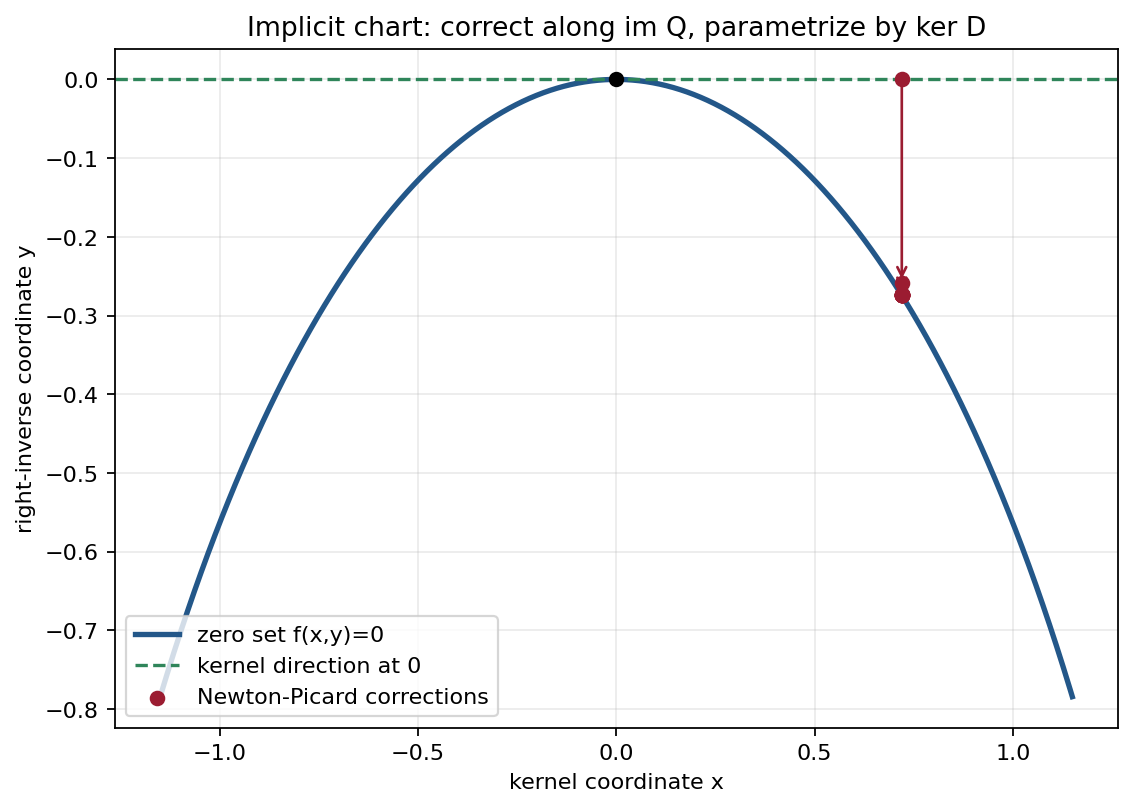

{'final_residual_small': True,
 'zero_set_tangent_to_kernel': True,
 'residuals_decrease': True}

In [5]:
def f_implicit(x, y):
    return y + 0.5 * x * x + 0.2 * y * y


def zero_branch(x):
    disc = np.maximum(1.0 - 0.4 * x * x, 0.0)
    return (-1.0 + np.sqrt(disc)) / 0.4


x_vals = np.linspace(-1.15, 1.15, 401)
y_vals = zero_branch(x_vals)
xi = 0.72
iterate_y = [0.0]
residuals = [float(abs(f_implicit(xi, iterate_y[-1])))]
for _ in range(12):
    y_next = iterate_y[-1] - f_implicit(xi, iterate_y[-1])
    iterate_y.append(float(y_next))
    residuals.append(float(abs(f_implicit(xi, iterate_y[-1]))))

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(x_vals, y_vals, color="#235789", linewidth=2.4, label="zero set f(x,y)=0")
ax.axhline(0, color="#2f855a", linestyle="--", linewidth=1.5, label="kernel direction at 0")
ax.scatter([xi] * len(iterate_y), iterate_y, color="#9b1c31", zorder=3, label="Newton-Picard corrections")
for y0, y1 in zip(iterate_y[:-1], iterate_y[1:]):
    ax.annotate("", xy=(xi, y1), xytext=(xi, y0), arrowprops={"arrowstyle": "->", "color": "#9b1c31", "lw": 1.2})
ax.scatter([0], [0], color="black", s=35, zorder=4)
ax.set_xlabel("kernel coordinate x")
ax.set_ylabel("right-inverse coordinate y")
ax.set_title("Implicit chart: correct along im Q, parametrize by ker D")
ax.grid(True, alpha=0.25)
ax.legend(loc="lower left")
fig.tight_layout()
implicit_fig = save_matplotlib(fig, UNIT, "figures", "implicit-newton-picard-chart.png")
plt.close(fig)

slope_at_origin = float((zero_branch(1e-5) - zero_branch(-1e-5)) / (2e-5))
implicit_check = {
    "model": "f(x,y)=y+0.5*x^2+0.2*y^2",
    "linearization_at_origin": "D(xi,eta)=eta",
    "kernel_dimension": 1,
    "right_inverse_direction": "Q(r)=(0,r)",
    "sample_kernel_coordinate": xi,
    "iteration_y_values": iterate_y,
    "residuals": residuals,
    "final_residual": residuals[-1],
    "zero_branch_slope_at_origin": slope_at_origin,
    "checks": {
        "final_residual_small": bool(residuals[-1] < 1e-10),
        "zero_set_tangent_to_kernel": bool(abs(slope_at_origin) < 1e-5),
        "residuals_decrease": bool(all(residuals[i + 1] <= residuals[i] + 1e-14 for i in range(len(residuals) - 1))),
    },
}
implicit_check["passed"] = all(implicit_check["checks"].values())
save_json(implicit_check, UNIT, "checks", "implicit-newton-picard.json")
display_artifact(implicit_fig, width=680)
implicit_check["checks"]


## A.4 Finite-Dimensional Reduction and the Kuranishi Model

At a singular point the derivative need not be onto, so the implicit function theorem cannot directly identify the zero set with the kernel. A pseudoinverse $T$ satisfying $TDT=T$ and $DTD=D$ creates projections onto image and cokernel directions. After a local change of coordinates, the equation has the form $f\circ g(x)=f_0(x)+Dx$.

The model below uses $D(u,v)=(0,v)$ and $T(a,b)=(0,b)$. The image equation is $v=0$; the obstruction equation is $\kappa_a(u)=u^2-a$.


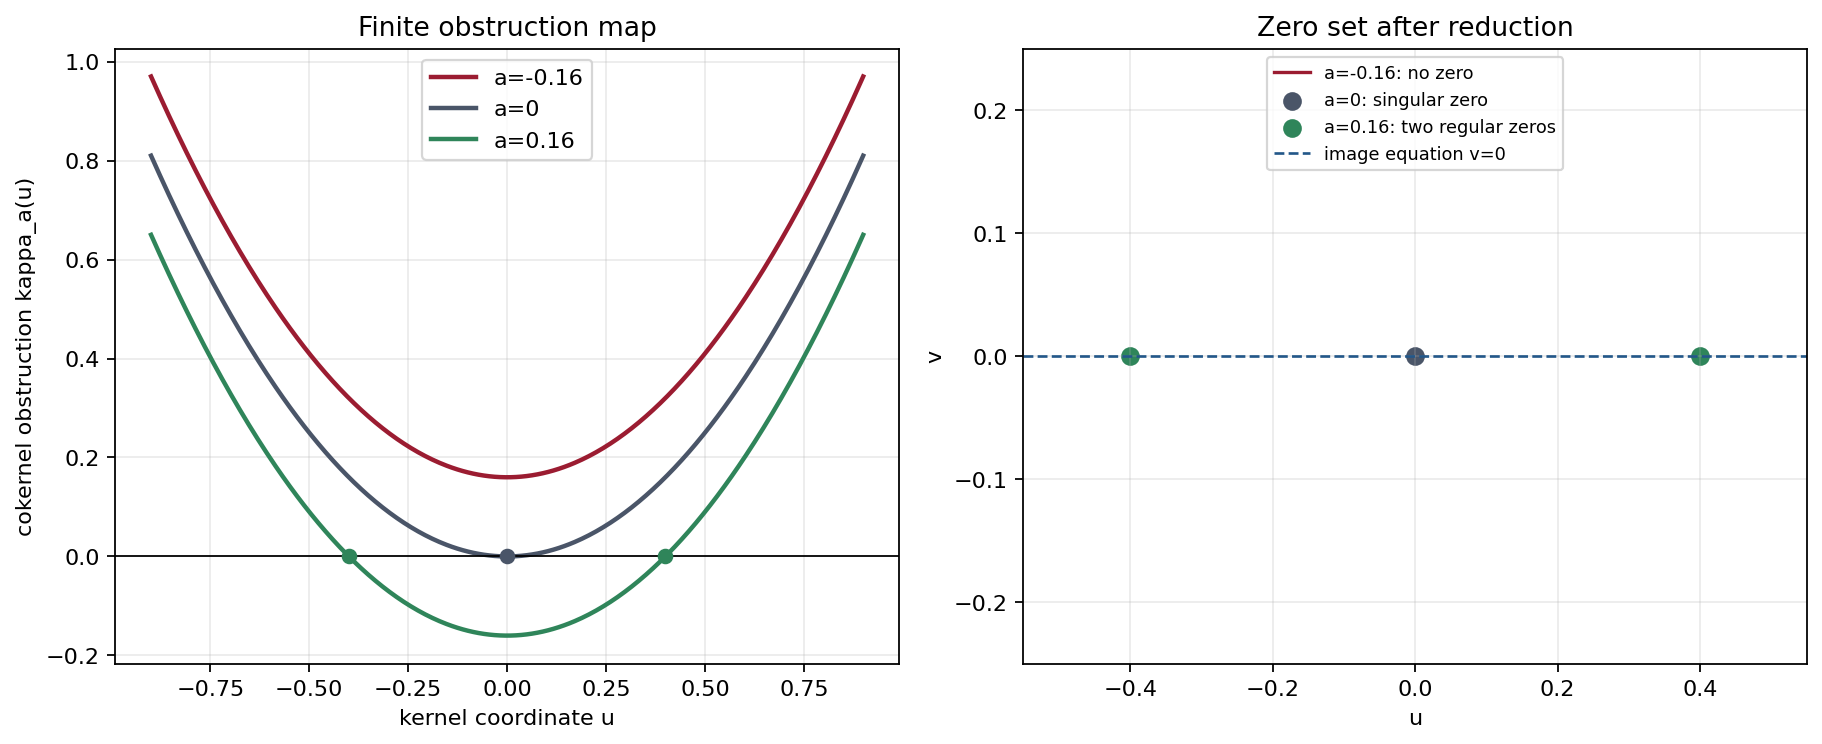

{'pseudoinverse_identity_TDT': True,
 'pseudoinverse_identity_DTD': True,
 'finite_obstruction_has_expected_counts': True,
 'singular_level_detected': True}

In [6]:
D_exact = sp.Matrix([[0, 0], [0, 1]])
T_exact = sp.Matrix([[0, 0], [0, 1]])
TDT_exact = T_exact * D_exact * T_exact
DTD_exact = D_exact * T_exact * D_exact

u_vals = np.linspace(-0.9, 0.9, 401)
levels = [-0.16, 0.0, 0.16]
level_colors = {-0.16: "#9b1c31", 0.0: "#4a5568", 0.16: "#2f855a"}
zero_count_rows = []

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for a in levels:
    kappa = u_vals ** 2 - a
    axes[0].plot(u_vals, kappa, color=level_colors[a], linewidth=2.0, label=f"a={a:g}")
    if a > 0:
        roots = [-math.sqrt(a), math.sqrt(a)]
    elif abs(a) < 1e-12:
        roots = [0.0]
    else:
        roots = []
    for root in roots:
        axes[0].scatter([root], [0], color=level_colors[a], s=36, zorder=4)
    zero_count_rows.append({"obstruction_level_a": a, "zero_count_near_origin": len(roots), "regular_roots": bool(a > 0), "singular_root_at_origin": bool(abs(a) < 1e-12)})
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("kernel coordinate u")
axes[0].set_ylabel("cokernel obstruction kappa_a(u)")
axes[0].set_title("Finite obstruction map")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

for row in zero_count_rows:
    a = row["obstruction_level_a"]
    if a > 0:
        roots = np.array([-math.sqrt(a), math.sqrt(a)])
        axes[1].scatter(roots, np.zeros_like(roots), color=level_colors[a], s=55, label=f"a={a:g}: two regular zeros")
    elif abs(a) < 1e-12:
        axes[1].scatter([0], [0], color=level_colors[a], s=55, label="a=0: singular zero")
    else:
        axes[1].plot([], [], color=level_colors[a], label=f"a={a:g}: no zero")
axes[1].axhline(0, color="#235789", linestyle="--", linewidth=1.2, label="image equation v=0")
axes[1].set_xlim(-0.55, 0.55)
axes[1].set_ylim(-0.25, 0.25)
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")
axes[1].set_title("Zero set after reduction")
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="upper center", fontsize=8)
fig.tight_layout()
kuranishi_fig = save_matplotlib(fig, UNIT, "figures", "kuranishi-obstruction-map.png")
plt.close(fig)

kuranishi_check = {
    "D_matrix": [[int(x) for x in row] for row in D_exact.tolist()],
    "T_matrix": [[int(x) for x in row] for row in T_exact.tolist()],
    "TDT_equals_T": bool(TDT_exact == T_exact),
    "DTD_equals_D": bool(DTD_exact == D_exact),
    "kernel_dimension": 1,
    "cokernel_dimension": 1,
    "index": 0,
    "obstruction_map": "kappa_a(u)=u^2-a",
    "zero_count_rows": zero_count_rows,
    "checks": {
        "pseudoinverse_identity_TDT": bool(TDT_exact == T_exact),
        "pseudoinverse_identity_DTD": bool(DTD_exact == D_exact),
        "finite_obstruction_has_expected_counts": bool([r["zero_count_near_origin"] for r in zero_count_rows] == [0, 1, 2]),
        "singular_level_detected": bool(any(r["singular_root_at_origin"] for r in zero_count_rows)),
    },
}
kuranishi_check["passed"] = all(kuranishi_check["checks"].values())
save_json(kuranishi_check, UNIT, "checks", "kuranishi-pseudoinverse-obstruction.json")
display_artifact(kuranishi_fig, width=760)
kuranishi_check["checks"]


## A.5 Sard-Smale as Finite Sard in Fredholm Coordinates

Sard-Smale says that for a sufficiently differentiable Fredholm map between separable Banach spaces, regular values form a residual set. The proof is local: split $X=X_0\oplus X_1$ and $Y=Y_0\oplus Y_1$, with $X_0=\ker D$ and $Y_0$ a cokernel complement, then write the equation as $y_0=f_0(x_0,x_1)$ and $y_1=D_1x_1$.

For each fixed $y_1$, regularity reduces to finite-dimensional Sard for $x_0\mapsto f_0(x_0,D_1^{-1}y_1)$. The finite model $(u,v)\mapsto (u^2,v)$ makes this reduction visible.


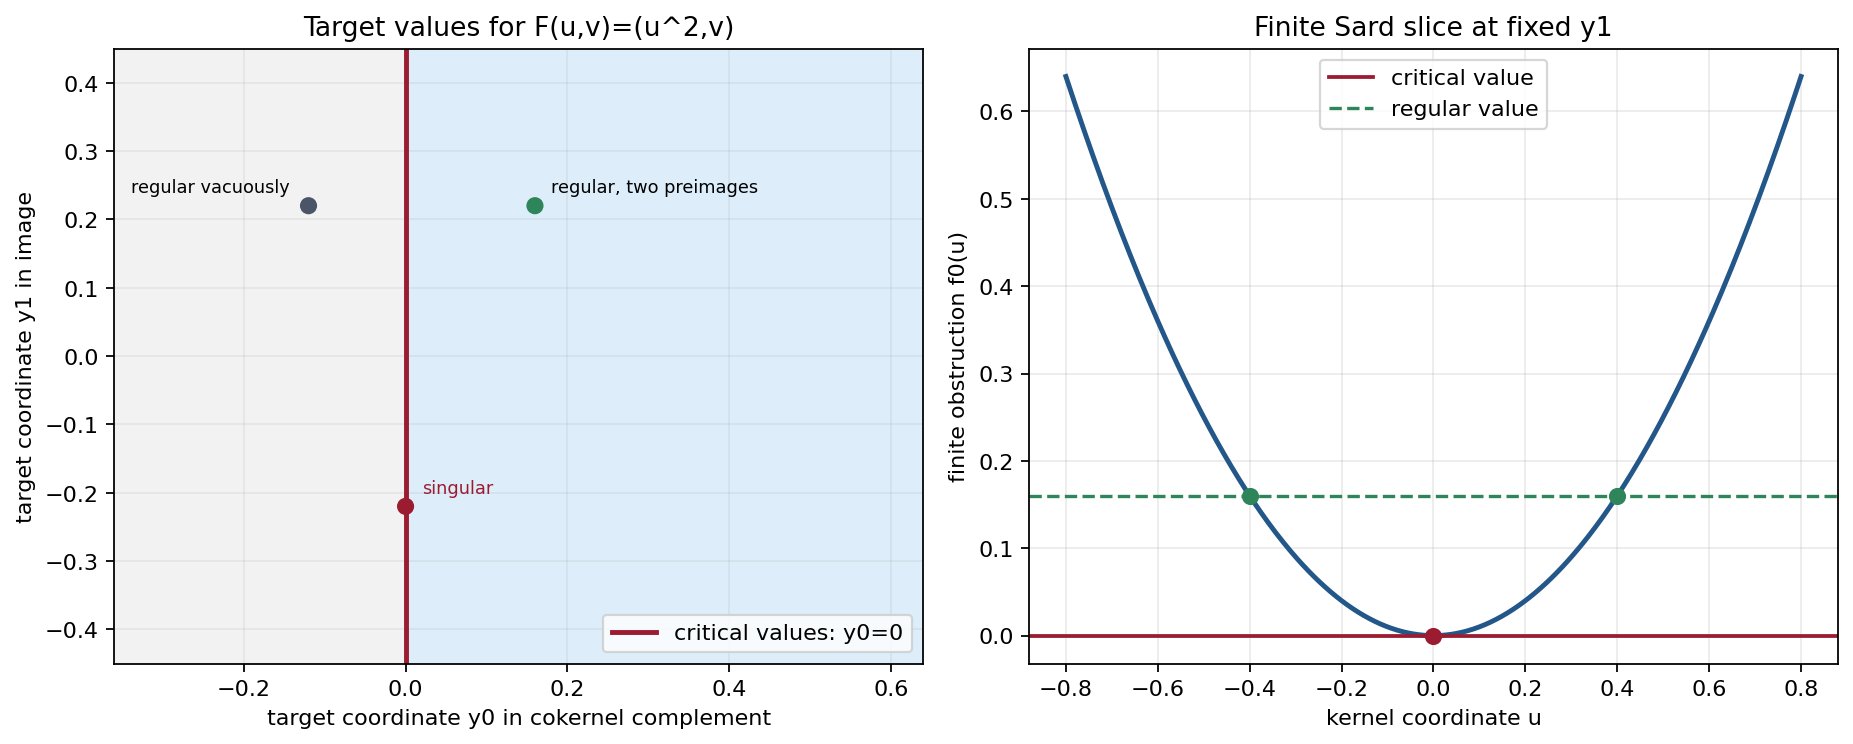

{'regular_preimage_ranks_full': True,
 'singular_rank_not_full': True,
 'critical_fraction_small_on_grid': True,
 'finite_sard_slice_identified': True}

In [7]:
def dF_rank_at(u):
    return int(np.linalg.matrix_rank(np.array([[2.0 * u, 0.0], [0.0, 1.0]]), tol=1e-10))


ys0 = np.linspace(-0.36, 0.64, 121)
ys1 = np.linspace(-0.45, 0.45, 91)
Y0, Y1 = np.meshgrid(ys0, ys1)
critical_mask = np.isclose(Y0, 0.0, atol=1e-12)
image_mask = Y0 >= 0.0

fig, axes = plt.subplots(1, 2, figsize=(11.7, 4.8))
axes[0].contourf(Y0, Y1, image_mask, levels=[-0.5, 0.5, 1.5], colors=["#f2f2f2", "#dceefa"], alpha=0.95)
axes[0].axvline(0, color="#9b1c31", linewidth=2.2, label="critical values: y0=0")
axes[0].scatter([0.16, -0.12, 0.0], [0.22, 0.22, -0.22], color=["#2f855a", "#4a5568", "#9b1c31"], s=45, zorder=3)
axes[0].text(0.18, 0.24, "regular, two preimages", fontsize=8)
axes[0].text(-0.34, 0.24, "regular vacuously", fontsize=8)
axes[0].text(0.02, -0.2, "singular", fontsize=8, color="#9b1c31")
axes[0].set_xlabel("target coordinate y0 in cokernel complement")
axes[0].set_ylabel("target coordinate y1 in image")
axes[0].set_title("Target values for F(u,v)=(u^2,v)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.2)

u = np.linspace(-0.8, 0.8, 401)
axes[1].plot(u, u ** 2, color="#235789", linewidth=2.2)
axes[1].axhline(0, color="#9b1c31", linewidth=1.7, label="critical value")
axes[1].axhline(0.16, color="#2f855a", linestyle="--", linewidth=1.5, label="regular value")
axes[1].scatter([-0.4, 0.4], [0.16, 0.16], color="#2f855a", s=45, zorder=3)
axes[1].scatter([0], [0], color="#9b1c31", s=45, zorder=3)
axes[1].set_xlabel("kernel coordinate u")
axes[1].set_ylabel("finite obstruction f0(u)")
axes[1].set_title("Finite Sard slice at fixed y1")
axes[1].grid(True, alpha=0.25)
axes[1].legend()
fig.tight_layout()
sard_fig = save_matplotlib(fig, UNIT, "figures", "sard-smale-finite-reduction.png")
plt.close(fig)

regular_two_preimages_ranks = [dF_rank_at(-0.4), dF_rank_at(0.4)]
singular_rank = dF_rank_at(0.0)
sampled_total = int(Y0.size)
sampled_critical = int(np.sum(critical_mask))
sard_check = {
    "model": "F(u,v)=(u^2,v)",
    "fredholm_index": 0,
    "critical_value_set": "target line y0=0",
    "sampled_target_values": sampled_total,
    "sampled_critical_values": sampled_critical,
    "sampled_critical_fraction": float(sampled_critical / sampled_total),
    "regular_value_with_two_preimages_derivative_ranks": regular_two_preimages_ranks,
    "singular_value_derivative_rank": singular_rank,
    "vacuous_regular_value_example": [-0.12, 0.22],
    "checks": {
        "regular_preimage_ranks_full": bool(all(rank == 2 for rank in regular_two_preimages_ranks)),
        "singular_rank_not_full": bool(singular_rank < 2),
        "critical_fraction_small_on_grid": bool(sampled_critical / sampled_total < 0.02),
        "finite_sard_slice_identified": True,
    },
}
sard_check["passed"] = all(sard_check["checks"].values())
save_json(sard_check, UNIT, "checks", "sard-smale-reduction.json")
display_artifact(sard_fig, width=780)
sard_check["checks"]


## Proof Visual: How Appendix A Feeds Moduli-Space Regularity

The graph below is a proof-state map rather than a theorem proof. Fredholm stability controls the index, determinant lines control orientation, implicit/Kuranishi models control the local zero set, and Sard-Smale supplies generic regularity.


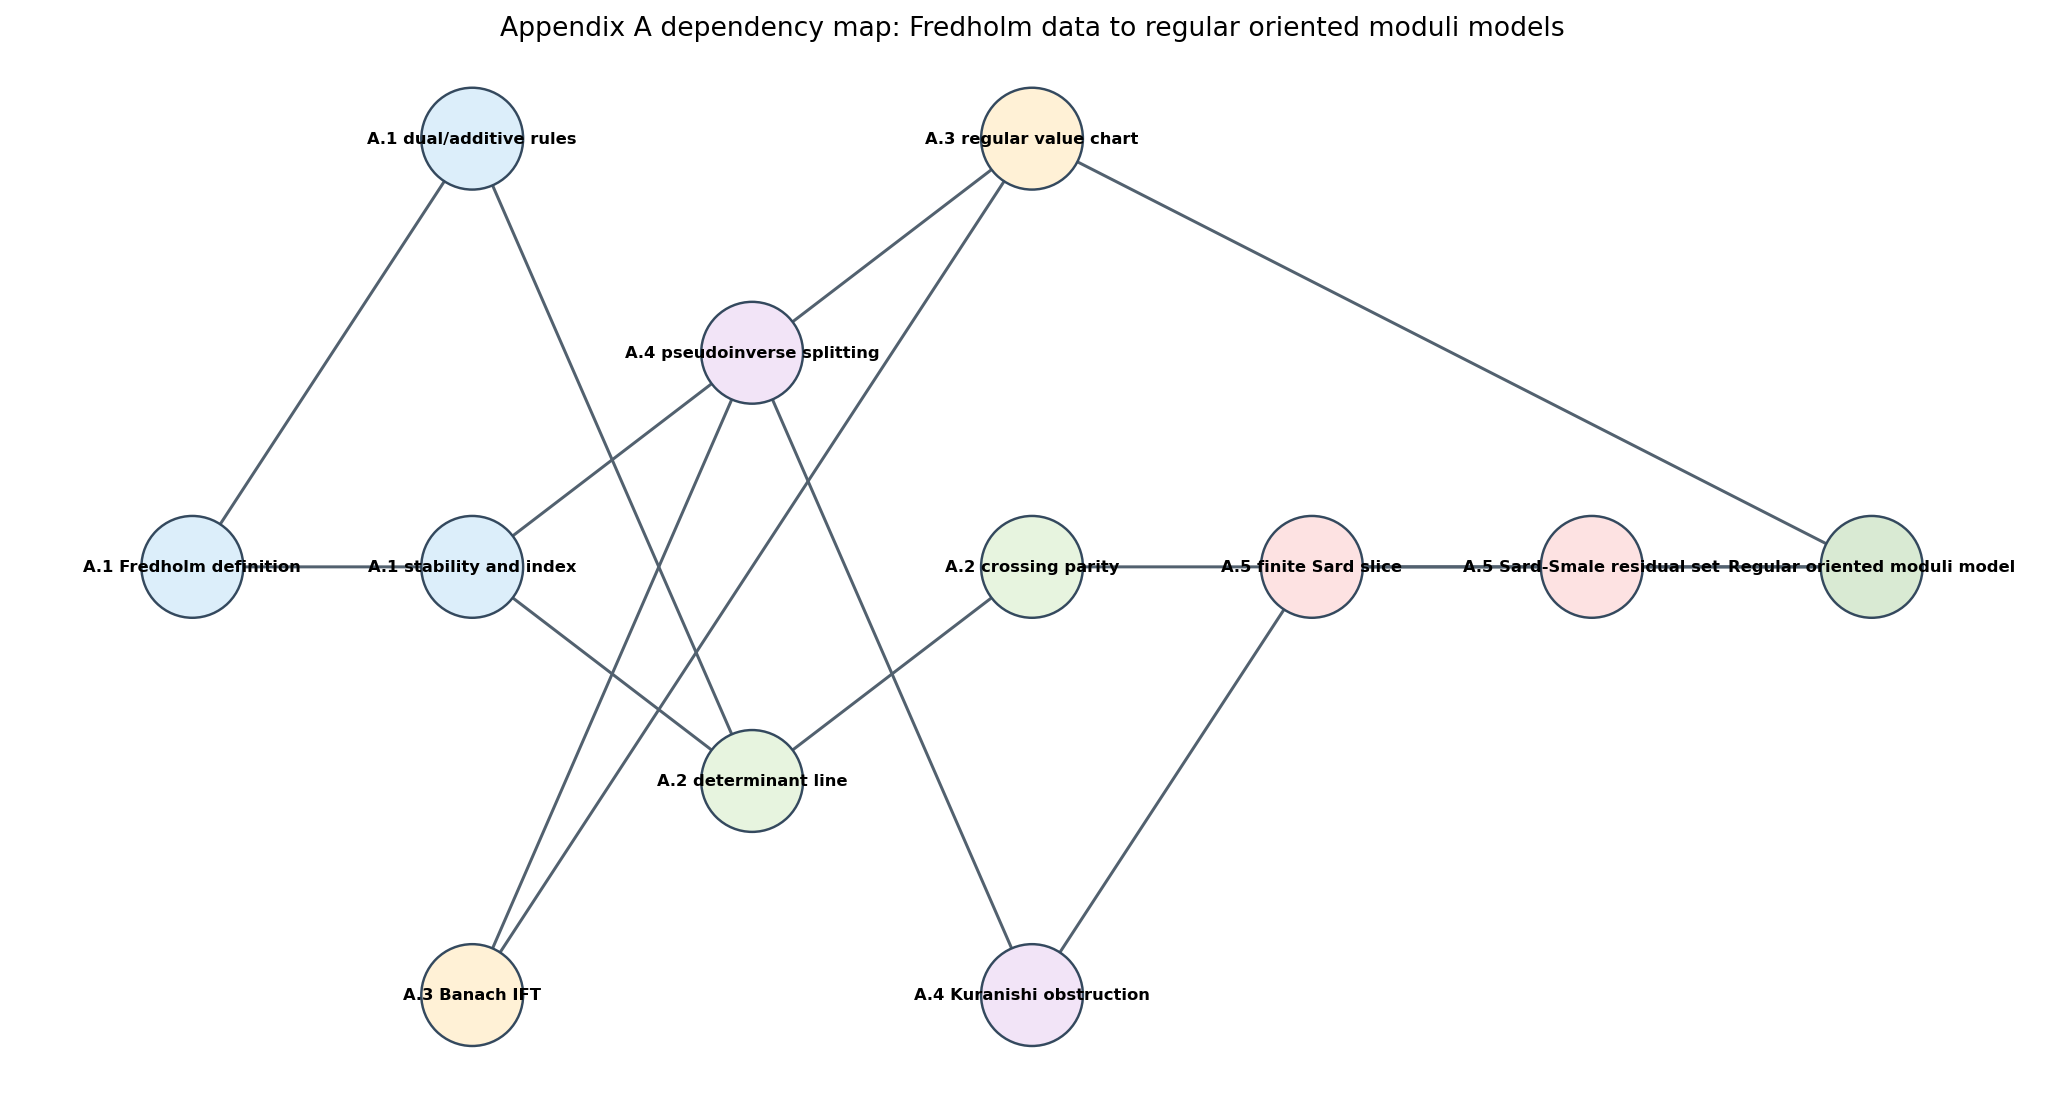

{'nodes': 12,
 'edges': 14,
 'is_directed_acyclic_graph': True,
 'source_sections_present': ['A.1', 'A.2', 'A.3', 'A.4', 'A.5'],
 'passed': True}

In [8]:
proof_nodes = ["A.1 Fredholm definition", "A.1 stability and index", "A.1 dual/additive rules", "A.2 determinant line", "A.2 crossing parity", "A.3 Banach IFT", "A.3 regular value chart", "A.4 pseudoinverse splitting", "A.4 Kuranishi obstruction", "A.5 finite Sard slice", "A.5 Sard-Smale residual set", "Regular oriented moduli model"]
proof_edges = [
    ("A.1 Fredholm definition", "A.1 stability and index"),
    ("A.1 Fredholm definition", "A.1 dual/additive rules"),
    ("A.1 stability and index", "A.2 determinant line"),
    ("A.1 dual/additive rules", "A.2 determinant line"),
    ("A.2 determinant line", "A.2 crossing parity"),
    ("A.3 Banach IFT", "A.3 regular value chart"),
    ("A.1 stability and index", "A.3 regular value chart"),
    ("A.4 pseudoinverse splitting", "A.4 Kuranishi obstruction"),
    ("A.3 Banach IFT", "A.4 pseudoinverse splitting"),
    ("A.4 Kuranishi obstruction", "A.5 finite Sard slice"),
    ("A.5 finite Sard slice", "A.5 Sard-Smale residual set"),
    ("A.2 crossing parity", "Regular oriented moduli model"),
    ("A.3 regular value chart", "Regular oriented moduli model"),
    ("A.5 Sard-Smale residual set", "Regular oriented moduli model"),
]
G = nx.DiGraph()
G.add_nodes_from(proof_nodes)
G.add_edges_from(proof_edges)
layer = {"A.1 Fredholm definition": 0, "A.1 stability and index": 1, "A.1 dual/additive rules": 1, "A.2 determinant line": 2, "A.2 crossing parity": 3, "A.3 Banach IFT": 1, "A.3 regular value chart": 3, "A.4 pseudoinverse splitting": 2, "A.4 Kuranishi obstruction": 3, "A.5 finite Sard slice": 4, "A.5 Sard-Smale residual set": 5, "Regular oriented moduli model": 6}
for node, value in layer.items():
    G.nodes[node]["layer"] = value
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.0)
for node, (x, y) in list(pos.items()):
    pos[node] = (x, y * 1.4)

fig, ax = plt.subplots(figsize=(13.0, 7.0))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=17, width=1.35, edge_color="#52616f")
node_colors = ["#dceefa" if "A.1" in n else "#e7f4df" if "A.2" in n else "#fff1d6" if "A.3" in n else "#f2e4f7" if "A.4" in n else "#fde2e2" if "A.5" in n else "#d9ead3" for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2100, node_color=node_colors, edgecolors="#34495e", linewidths=1.1)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.4, font_weight="bold")
ax.set_title("Appendix A dependency map: Fredholm data to regular oriented moduli models")
ax.set_axis_off()
fig.tight_layout()
proof_fig = save_matplotlib(fig, UNIT, "figures", "fredholm-proof-dependency-map.png")
plt.close(fig)

proof_check = {"nodes": len(G.nodes), "edges": len(G.edges), "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G), "source_sections_present": ["A.1", "A.2", "A.3", "A.4", "A.5"], "passed": bool(len(G.nodes) >= 10 and nx.is_directed_acyclic_graph(G))}
save_json(proof_check, UNIT, "checks", "fredholm-proof-dependency-map.json")
display_artifact(proof_fig, width=820)
proof_check


## Invariant Ledger

This table is the notebook's compact audit sheet. Each row names a source concept, the finite computational object used to represent it, the artifact that exposes it, and the validation check that prevents the visual from becoming decorative.


In [9]:
ledger_rows = [
    {"source_section": "A.1", "concept": "Fredholm index", "computational_object": "rectangular matrix with finite kernel and cokernel", "artifact": "figures/fredholm-index-stability-criterion.png", "check": "rank-nullity and index stability under small perturbation"},
    {"source_section": "A.1", "concept": "compact criterion and index rules", "computational_object": "stacked estimate [D;K0], composition T D, and adjoint D.T", "artifact": "checks/fredholm-stability-index-relations.json", "check": "positive lower bound, index(TD)=index(T)+index(D), index(D*)=-index(D)"},
    {"source_section": "A.2", "concept": "determinant-line orientation", "computational_object": "index-zero diagonal paths with regular crossings", "artifact": "figures/determinant-line-crossing-sign.png", "check": "endpoint sign ratio equals (-1)^crossing_index"},
    {"source_section": "A.3", "concept": "implicit function chart", "computational_object": "zero curve corrected along the right-inverse direction", "artifact": "figures/implicit-newton-picard-chart.png", "check": "Newton-Picard residual decreases and zero curve is tangent to kernel"},
    {"source_section": "A.4", "concept": "Kuranishi obstruction", "computational_object": "pseudoinverse splitting and scalar map kappa_a(u)=u^2-a", "artifact": "figures/kuranishi-obstruction-map.png", "check": "TDT=T, DTD=D, and zero-count ledger matches obstruction level"},
    {"source_section": "A.5", "concept": "Sard-Smale local reduction", "computational_object": "target-plane critical value set for F(u,v)=(u^2,v)", "artifact": "figures/sard-smale-finite-reduction.png", "check": "regular preimages have full derivative rank and critical set is thin on grid"},
]
ledger_path = write_csv(TABLE_DIR / "fredholm-invariant-ledger.csv", ledger_rows, ["source_section", "concept", "computational_object", "artifact", "check"])
ledger_check = {"row_count": len(ledger_rows), "sections": sorted({row["source_section"] for row in ledger_rows}), "all_rows_have_artifacts": all(row["artifact"] for row in ledger_rows), "all_rows_have_checks": all(row["check"] for row in ledger_rows)}
ledger_check["passed"] = bool(ledger_check["row_count"] >= 6 and ledger_check["sections"] == ["A.1", "A.2", "A.3", "A.4", "A.5"] and ledger_check["all_rows_have_checks"])
save_json(ledger_check, UNIT, "checks", "fredholm-invariant-ledger.json")
display_artifact(ledger_path)
ledger_check


{'row_count': 6,
 'sections': ['A.1', 'A.2', 'A.3', 'A.4', 'A.5'],
 'all_rows_have_artifacts': True,
 'all_rows_have_checks': True,
 'passed': True}

## Applied Lab: Change One Assumption and Watch the Model Break

1. In the Fredholm cell, increase the perturbation size. The dimensions of kernel and cokernel may change, but the finite model's index remains `domain_dimension - target_dimension`.
2. In the determinant crossing cell, add a third crossing. The endpoint orientation sign should flip again.
3. In the implicit-function cell, move `xi` closer to the edge of the plotted interval. The fixed derivative correction eventually stops being a good contraction, showing why the theorem is local.
4. In the Kuranishi cell, change the obstruction level `a`. The finite obstruction map records whether a singular point unfolds into two regular zeros, stays singular, or disappears.
5. In the Sard-Smale cell, replace `u**2` by `u**3`. The critical value set is still thin, but the regularity test at the origin changes order.

The point is not that these finite models prove the Banach-space theorems. They expose the finite-dimensional data that the theorems preserve.


## Takeaways and Sanity Checks

- A Fredholm operator has finite kernel and cokernel, and its index is stable under compact and small perturbations.
- The determinant line turns kernel/cokernel orientations into a one-dimensional orientation object; regular crossings change its sign by parity.
- A regular value gives a smooth zero set whose tangent space is the kernel of the linearization.
- A pseudoinverse separates image equations from finite cokernel obstructions, producing a Kuranishi model near singular points.
- Sard-Smale applies finite-dimensional Sard to local Fredholm coordinates and patches the result using separability.

The final cell validates artifact existence, nonzero sizes, and the numeric/symbolic invariants that each section relies on.


In [10]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "source-coverage-fredholm-theory.json",
    CHECK_DIR / "visual-storyboard-fredholm-theory.json",
    CHECK_DIR / "fredholm-stability-index-relations.json",
    CHECK_DIR / "determinant-crossing-signs.json",
    CHECK_DIR / "implicit-newton-picard.json",
    CHECK_DIR / "kuranishi-pseudoinverse-obstruction.json",
    CHECK_DIR / "sard-smale-reduction.json",
    CHECK_DIR / "fredholm-proof-dependency-map.json",
    CHECK_DIR / "fredholm-invariant-ledger.json",
    FIG_DIR / "fredholm-index-stability-criterion.png",
    FIG_DIR / "determinant-line-crossing-sign.png",
    FIG_DIR / "implicit-newton-picard-chart.png",
    FIG_DIR / "kuranishi-obstruction-map.png",
    FIG_DIR / "sard-smale-finite-reduction.png",
    FIG_DIR / "fredholm-proof-dependency-map.png",
    TABLE_DIR / "fredholm-invariant-ledger.csv",
]
for artifact in expected_artifacts:
    min_bytes = 96 if artifact.suffix in {".csv", ".json"} else 1024
    assert_artifact(artifact, min_bytes=min_bytes)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=256)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=256)

json_checks = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "source-coverage-fredholm-theory.json",
    CHECK_DIR / "visual-storyboard-fredholm-theory.json",
    CHECK_DIR / "fredholm-stability-index-relations.json",
    CHECK_DIR / "determinant-crossing-signs.json",
    CHECK_DIR / "implicit-newton-picard.json",
    CHECK_DIR / "kuranishi-pseudoinverse-obstruction.json",
    CHECK_DIR / "sard-smale-reduction.json",
    CHECK_DIR / "fredholm-proof-dependency-map.json",
    CHECK_DIR / "fredholm-invariant-ledger.json",
]
loaded = {path.name: json.loads(path.read_text(encoding="utf-8")) for path in json_checks}
for name, payload in loaded.items():
    assert payload.get("passed") is True, name

fredholm_payload = loaded["fredholm-stability-index-relations.json"]
assert fredholm_payload["checks"]["composition_additivity"]
assert fredholm_payload["checks"]["dual_relation"]
assert fredholm_payload["checks"]["small_perturbation_index_stable"]

crossing_payload = loaded["determinant-crossing-signs.json"]
assert all(path["sign_formula_ok"] for path in crossing_payload["paths"])

implicit_payload = loaded["implicit-newton-picard.json"]
assert implicit_payload["final_residual"] < 1e-10
assert abs(implicit_payload["zero_branch_slope_at_origin"]) < 1e-5

kuranishi_payload = loaded["kuranishi-pseudoinverse-obstruction.json"]
assert kuranishi_payload["TDT_equals_T"] and kuranishi_payload["DTD_equals_D"]

sard_payload = loaded["sard-smale-reduction.json"]
assert sard_payload["singular_value_derivative_rank"] < 2
assert all(rank == 2 for rank in sard_payload["regular_value_with_two_preimages_derivative_ranks"])

final_sanity = {
    "passed": True,
    "expected_artifacts": len(expected_artifacts),
    "json_checks": len(json_checks),
    "source_sections": len(source_coverage),
    "storyboard_items": len(visual_storyboard),
    "checks": ["artifact existence", "JSON passed flags", "Fredholm index identities", "orientation crossings", "implicit/Kuranishi/Sard-Smale checks"],
}
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json", min_bytes=128)
print(f"Validated {len(expected_artifacts)} Appendix A artifacts and {len(json_checks)} invariant ledgers.")


Validated 19 Appendix A artifacts and 12 invariant ledgers.
